# Detecção de Pneumonia em Radiografias com CNN

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

A pneumonia é uma infecção que pode comprometer os pulmões e exige diagnóstico rápido, principalmente em crianças, idosos e pacientes com maior risco clínico. Radiografias de tórax são exames amplamente utilizados nesse processo, mas sua interpretação depende de experiência médica e pode ser afetada por qualidade da imagem, sobreposição de estruturas e variações entre pacientes.

Neste notebook, aplicamos **Redes Neurais Convolucionais (CNNs)** para classificar radiografias de tórax em duas classes: **Normal** e **Pneumonia**. O objetivo é construir uma solução experimental capaz de apoiar a triagem de exames, sempre considerando que o diagnóstico final deve ser realizado por um profissional de saúde.

### Dataset

Utilizamos o dataset **Chest X-Ray Images (Pneumonia)**, disponível no Kaggle e carregado automaticamente via `kagglehub`.

- **Fonte:** [Chest X-Ray Images (Pneumonia) - Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
- **Autor:** Paul Timothy Mooney
- **Tamanho:** aproximadamente 5.800 imagens JPEG
- **Classes:** `NORMAL` e `PNEUMONIA`
- **Divisão original:** `train/`, `val/`, `test/`

### Objetivo

Treinar e comparar dois modelos de classificação de imagens:

- Uma **CNN construída do zero**, usada como baseline;
- Um modelo com **Transfer Learning usando MobileNetV2**, seguido de fine-tuning.

A avaliação considera métricas relevantes para o contexto médico, com atenção especial ao **Recall da classe Pneumonia**, pois um falso negativo significa classificar um paciente com pneumonia como normal.

---

### Estrutura do Notebook

1. Importação das Bibliotecas
2. Carregamento e Exploração dos Dados
3. Pré-processamento e Data Augmentation
4. Modelo 1 - CNN do Zero
5. Modelo 2 - Transfer Learning com MobileNetV2
6. Treinamento e Avaliação
7. Interpretabilidade com Grad-CAM
8. Discussão Crítica

## 1. Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para manipulação dos dados, visualização, processamento de imagens, construção dos modelos e avaliação das métricas.

Também definimos uma semente fixa (`SEED = 42`) para reduzir variações entre execuções. Em redes neurais, a reprodutibilidade pode não ser perfeita por causa de operações internas do TensorFlow, mas a definição da semente torna o experimento mais controlado.

As principais bibliotecas utilizadas são:

- `PIL` e `cv2`: leitura, redimensionamento e manipulação das imagens;
- `matplotlib` e `seaborn`: visualização dos dados e resultados;
- `tensorflow.keras`: construção, treinamento e avaliação das redes neurais;
- `MobileNetV2`: arquitetura pré-treinada usada no Transfer Learning;
- `sklearn.metrics`: métricas de classificação, matriz de confusão e curva ROC.

In [1]:
import os
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(f'TensorFlow versão: {tf.__version__}')
print(f'GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow versão: 2.21.0
GPU disponível: False


## 2. Carregamento e Exploração dos Dados (EDA)

Antes da modelagem, é necessário entender a estrutura do dataset, a distribuição das classes e as características básicas das imagens. Essa etapa ajuda a identificar decisões importantes de pré-processamento, como redimensionamento, normalização, aumento de dados e tratamento de desbalanceamento.

### 2.1 Download do Dataset

O dataset é baixado via `kagglehub`. Para executar esta célula, é necessário ter as credenciais da API do Kaggle configuradas no ambiente.

**Alternativa manual:** baixar o dataset diretamente no Kaggle e apontar `DATA_DIR` para a pasta `chest_xray`.

In [2]:
import kagglehub

DATA_DIR_KAGGLE = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
print(f'Dataset baixado em: {DATA_DIR_KAGGLE}')

# Localiza a pasta chest_xray dentro do diretório baixado
candidates = list(DATA_DIR_KAGGLE.rglob('chest_xray'))
if candidates:
    DATA_DIR = candidates[0]
else:
    DATA_DIR = DATA_DIR_KAGGLE

print(f'Usando diretório base: {DATA_DIR}')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

for split, path in [('Treino', TRAIN_DIR), ('Validação', VAL_DIR), ('Teste', TEST_DIR)]:
    normal    = len(list((path / 'NORMAL').glob('*.jpeg')) + list((path / 'NORMAL').glob('*.jpg')))
    pneumonia = len(list((path / 'PNEUMONIA').glob('*.jpeg')) + list((path / 'PNEUMONIA').glob('*.jpg')))
    print(f'{split:12s} | NORMAL: {normal:5d} | PNEUMONIA: {pneumonia:5d} | Total: {normal+pneumonia:5d}')

Dataset baixado em: C:\Users\marco\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Usando diretório base: C:\Users\marco\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray
Treino       | NORMAL:  1341 | PNEUMONIA:  3875 | Total:  5216
Validação    | NORMAL:     8 | PNEUMONIA:     8 | Total:    16
Teste        | NORMAL:   234 | PNEUMONIA:   390 | Total:   624


### 2.1.1 Estrutura observada do dataset

O dataset já vem separado em treino, validação e teste. Essa separação será respeitada para evitar vazamento de dados.

Um ponto importante é que o conjunto de validação original é muito pequeno: apenas 16 imagens. Isso torna métricas como `val_accuracy` e `val_recall` bastante instáveis, porque poucos acertos ou erros mudam muito o resultado percentual.

Por isso, a validação é útil para acompanhar o treinamento, mas a comparação mais confiável entre modelos deve ser feita no conjunto de teste.

### 2.2 Distribuição das Classes

A distribuição das classes é uma etapa essencial em problemas de classificação médica. Se uma classe aparece muito mais que a outra, o modelo pode aprender a favorecer a classe majoritária e ainda assim apresentar uma acurácia aparentemente boa.

Neste dataset, o conjunto de treino possui mais exemplos de **Pneumonia** do que de **Normal**. Isso influencia diretamente a escolha das métricas e justifica o uso de `class_weight` durante o treinamento.

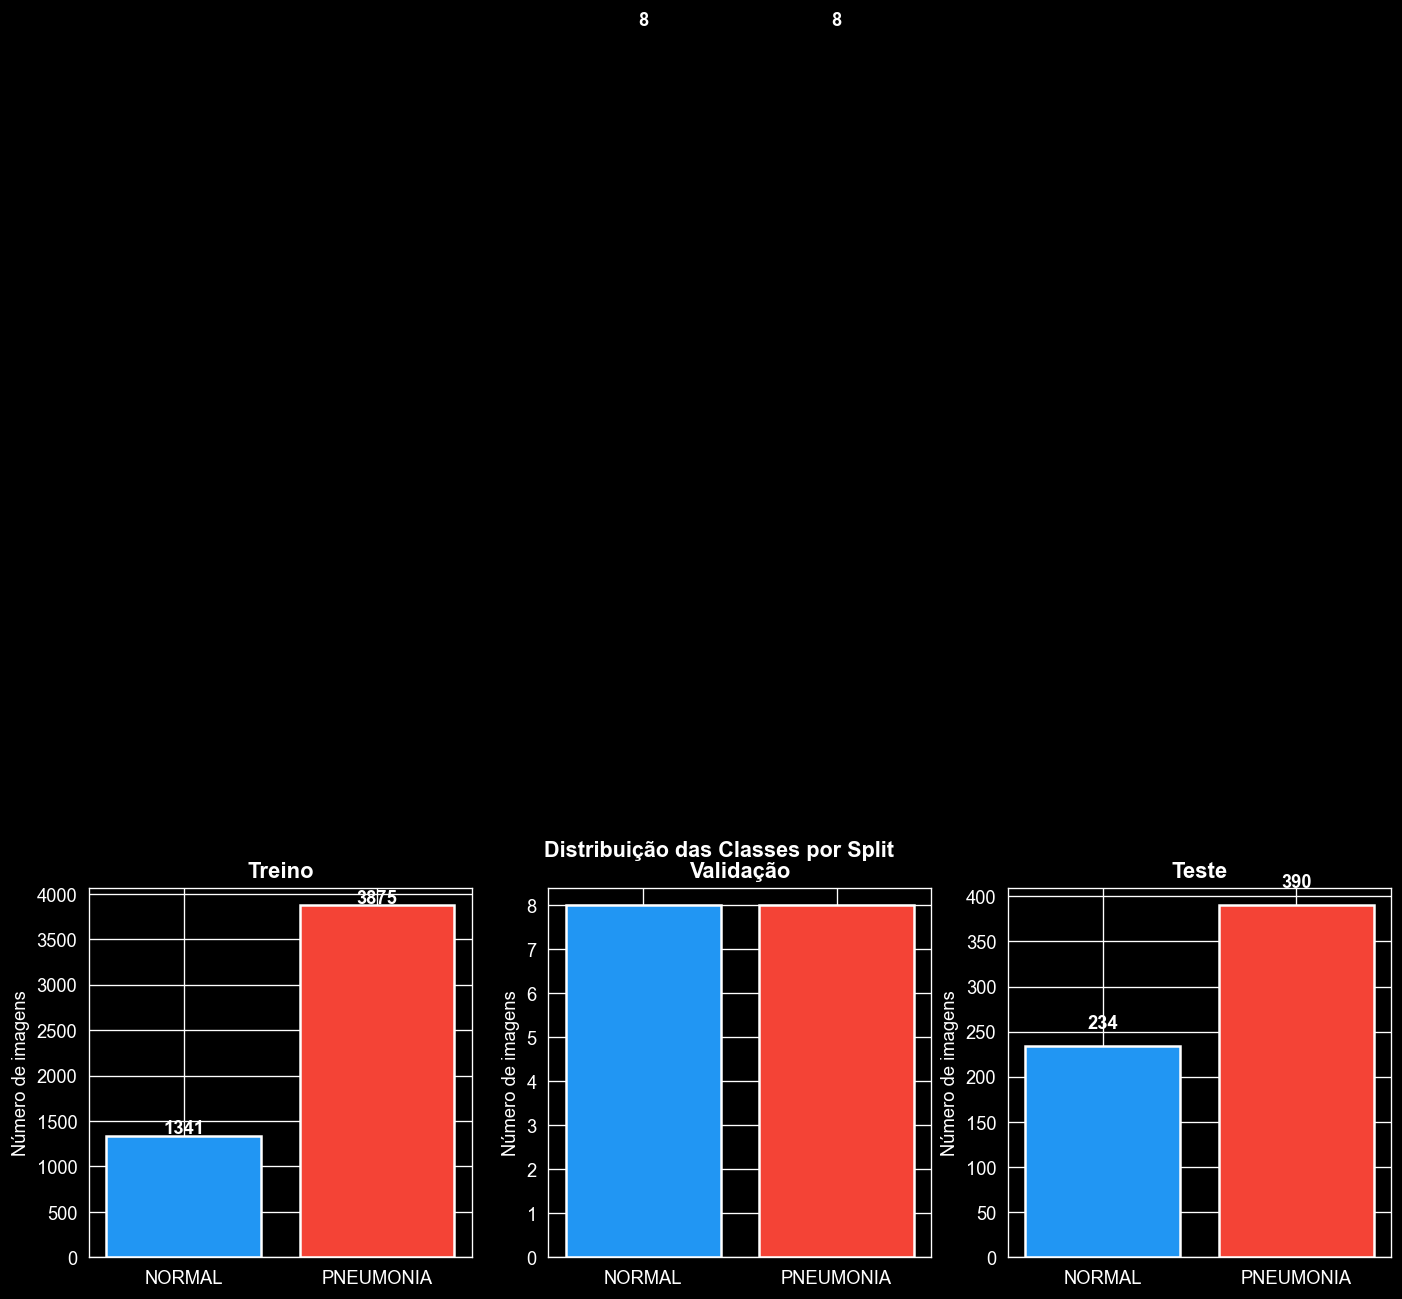


Observação: o conjunto de TREINO apresenta desbalanceamento de classes.
A relação Pneumonia/Normal é de aproximadamente 3:1 no treino.
Estratégias para lidar: class_weight, data augmentation seletiva.


In [3]:
splits = {'Treino': TRAIN_DIR, 'Validação': VAL_DIR, 'Teste': TEST_DIR}
contagens = {}

for split, path in splits.items():
    n = len(list((path / 'NORMAL').glob('*.*')))
    p = len(list((path / 'PNEUMONIA').glob('*.*')))
    contagens[split] = {'NORMAL': n, 'PNEUMONIA': p}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cores = ['#2196F3', '#F44336']

for ax, (split, vals) in zip(axes, contagens.items()):
    bars = ax.bar(vals.keys(), vals.values(), color=cores, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split}', fontweight='bold')
    ax.set_ylabel('Número de imagens')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', fontweight='bold')

plt.suptitle('Distribuição das Classes por Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/cnn_distribuicao_classes.png', bbox_inches='tight')
plt.show()

print('\nObservação: o conjunto de TREINO apresenta desbalanceamento de classes.')
print('A relação Pneumonia/Normal é de aproximadamente 3:1 no treino.')
print('Estratégias para lidar: class_weight, data augmentation seletiva.')

### Análise do balanceamento das classes

O conjunto de treino é desbalanceado, com predominância de imagens de pneumonia. Esse comportamento é comum em bases médicas públicas, mas precisa ser tratado porque pode influenciar o aprendizado.

Se não fizermos nenhum ajuste, o modelo pode favorecer a classe majoritária e ter dificuldade em reconhecer radiografias normais. Ao mesmo tempo, no contexto clínico, também precisamos garantir alta sensibilidade para pneumonia.

Neste notebook, a estratégia escolhida foi usar `class_weight`, atribuindo maior peso à classe menos frequente durante o cálculo da perda. Essa abordagem evita duplicar imagens artificialmente e mantém o conjunto de treino original.

### 2.3 Visualização de Amostras

A visualização de exemplos reais ajuda a compreender o problema além dos números. Em radiografias normais, espera-se observar campos pulmonares mais claros e sem opacidades importantes. Em casos de pneumonia, podem aparecer áreas esbranquiçadas ou opacificações relacionadas à inflamação/infiltrado.

Essa análise visual não substitui interpretação médica, mas ajuda a validar se as imagens foram carregadas corretamente e se as classes fazem sentido para o problema.

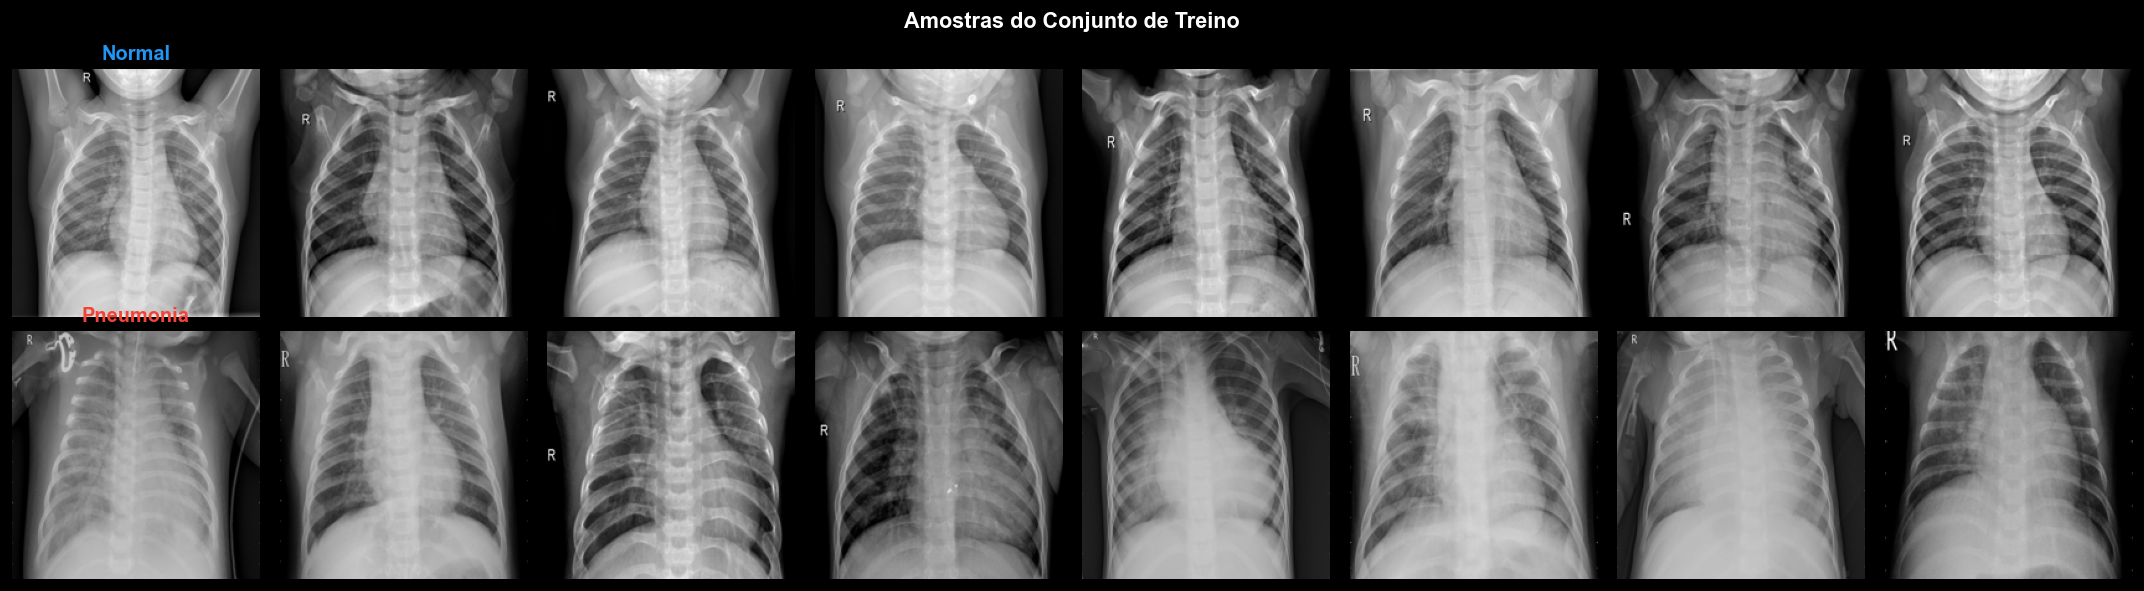

Radiografias NORMAIS: pulmão claro, sem opacidades.
Radiografias com PNEUMONIA: regiões de opacidade (brancas) nos pulmões.


In [4]:
def mostrar_amostras(diretorio, classe, n=4, titulo_prefixo=''):
    imgs = list((diretorio / classe).glob('*.*'))[:n]
    return imgs

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
classes = ['NORMAL', 'PNEUMONIA']
rotulos = ['Normal', 'Pneumonia']
cores_titulo = ['#2196F3', '#F44336']

for row, (cls, label, cor) in enumerate(zip(classes, rotulos, cores_titulo)):
    imgs = list((TRAIN_DIR / cls).glob('*.*'))[:8]
    for col, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('RGB').resize((200, 200))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(label, color=cor, fontweight='bold', fontsize=12)

plt.suptitle('Amostras do Conjunto de Treino', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/cnn_amostras.png', bbox_inches='tight')
plt.show()

print('Radiografias NORMAIS: pulmão claro, sem opacidades.')
print('Radiografias com PNEUMONIA: regiões de opacidade (brancas) nos pulmões.')

### Análise visual das amostras

A diferença entre as classes nem sempre é óbvia visualmente. Algumas radiografias com pneumonia apresentam opacidades bem marcadas, enquanto outras podem ser mais sutis. Da mesma forma, radiografias normais podem variar bastante por posicionamento, contraste e qualidade de aquisição.

Essa variabilidade reforça por que o problema é adequado para CNNs: a rede tenta aprender padrões espaciais e texturais diretamente da imagem. Ainda assim, a análise visual também mostra por que a avaliação deve ser criteriosa. Um bom desempenho no dataset não garante que o modelo generalize para imagens de outros hospitais ou equipamentos.

### 2.4 Estatísticas das Imagens

Redes neurais convolucionais exigem entradas com dimensões fixas dentro de um mesmo lote. Como as radiografias do dataset possuem tamanhos variados, precisamos avaliar suas dimensões originais e definir um tamanho padrão para treinamento.

O tamanho escolhido foi **224 x 224 pixels**, compatível com a MobileNetV2 e suficientemente leve para treinamento em máquina local.

In [5]:
larguras, alturas = [], []
sample_imgs = list(TRAIN_DIR.rglob('*.*'))[:300]

for img_path in sample_imgs:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            larguras.append(w)
            alturas.append(h)
    except Exception:
        pass

print('=== Dimensões das imagens (amostra de 300) ===')
print(f'Largura  — mín: {min(larguras):4d} | máx: {max(larguras):4d} | média: {np.mean(larguras):.0f}')
print(f'Altura   — mín: {min(alturas):4d} | máx: {max(alturas):4d} | média: {np.mean(alturas):.0f}')
print()
print('As imagens têm dimensões variadas → precisamos redimensionar para um tamanho fixo.')
print('Escolha: 224×224 px (padrão para redes pré-treinadas como MobileNetV2).')

=== Dimensões das imagens (amostra de 300) ===
Largura  — mín:  994 | máx: 2538 | média: 1670
Altura   — mín:  747 | máx: 2411 | média: 1351

As imagens têm dimensões variadas → precisamos redimensionar para um tamanho fixo.
Escolha: 224×224 px (padrão para redes pré-treinadas como MobileNetV2).


### Decisão sobre redimensionamento

As dimensões originais das imagens variam bastante. O redimensionamento para `224 x 224` padroniza a entrada e permite usar a MobileNetV2 sem adaptações estruturais.

Essa escolha envolve um trade-off: imagens menores reduzem custo computacional e memória, mas podem perder detalhes finos. Para este desafio, `224 x 224` é uma escolha prática e compatível com arquiteturas pré-treinadas. Em um projeto clínico real, faria sentido testar resoluções maiores e comparar o impacto nas métricas.

## 3. Pré-processamento e Data Augmentation

O pré-processamento prepara as imagens para entrada nos modelos. Como estamos lidando com imagens médicas, essa etapa precisa ser feita com cuidado: transformações muito agressivas podem criar exemplos irreais e prejudicar a interpretação clínica.

### Estratégia adotada

- **Redimensionamento:** todas as imagens são convertidas para `224 x 224`.
- **Normalização:** os pixels são reescalados para o intervalo `[0, 1]`.
- **Data Augmentation:** aplicado apenas no treino, com rotações e deslocamentos leves.
- **Validação e teste sem augmentation:** mantidos o mais próximos possível das imagens originais.
- **Desbalanceamento:** tratado com `class_weight`, dando maior peso à classe minoritária.

Um cuidado importante é evitar vazamento de dados: qualquer transformação aleatória deve ser aplicada apenas ao treino. Validação e teste devem representar a avaliação real do modelo.

In [6]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
CLASSES    = ['NORMAL', 'PNEUMONIA']

# Gerador de treino com augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
)

# Geradores de validação e teste — apenas normalização, sem augmentation
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASSES, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASSES, seed=SEED
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASSES, seed=SEED, shuffle=False
)

print(f'Índice das classes: {train_gen.class_indices}')
print(f'  0 = NORMAL | 1 = PNEUMONIA')
print(f'Passos por época (treino): {len(train_gen)}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Índice das classes: {'NORMAL': 0, 'PNEUMONIA': 1}
  0 = NORMAL | 1 = PNEUMONIA
Passos por época (treino): 163


In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos para compensar o desbalanceamento NORMAL vs PNEUMONIA
labels_treino = train_gen.classes
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=labels_treino
)
class_weight_dict = {0: pesos[0], 1: pesos[1]}
print(f'Pesos das classes: {class_weight_dict}')
print('Peso maior para NORMAL pois é a classe minoritária no treino.')

Pesos das classes: {0: 1.9448173005219984, 1: 0.6730322580645162}
Peso maior para NORMAL pois é a classe minoritária no treino.


### 3.1 Tratamento do desbalanceamento com `class_weight`

O cálculo de `class_weight` aumenta o peso da classe menos frequente no treino. Na prática, erros nessa classe passam a ter impacto maior na função de perda.

Essa escolha é preferível a oversampling simples neste notebook, porque evita repetir imagens e reduzir diversidade efetiva do treino. Também é uma solução simples e compatível com o `model.fit` do Keras.

A aplicação dos pesos deve ser analisada junto com a matriz de confusão. Se o modelo passar a gerar falsos positivos demais, pode ser necessário ajustar o limiar de decisão ou testar outras estratégias.

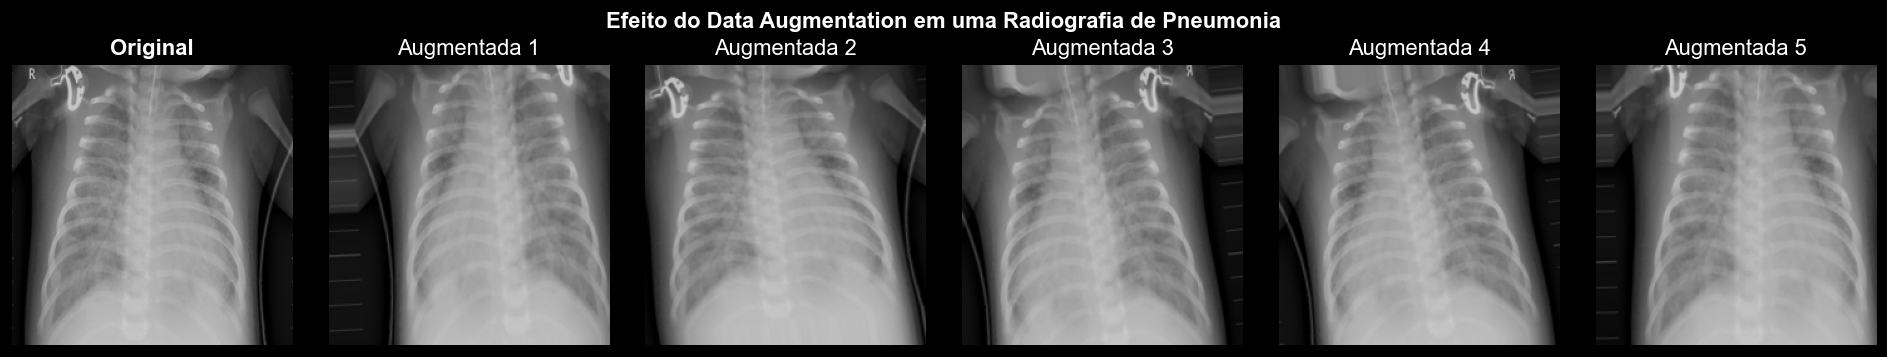

In [8]:
# Visualizar efeito do data augmentation
sample_img_path = list((TRAIN_DIR / 'PNEUMONIA').glob('*.*'))[0]
img_orig = np.array(Image.open(sample_img_path).convert('RGB').resize(IMG_SIZE))
img_expanded = img_orig[np.newaxis, ...].astype('float32')

aug_gen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True
).flow(img_expanded, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(img_orig)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = next(aug_gen)[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentada {i}')
    axes[i].axis('off')

plt.suptitle('Efeito do Data Augmentation em uma Radiografia de Pneumonia', fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/cnn_augmentation.png', bbox_inches='tight')
plt.show()

### 3.2 Análise do Data Augmentation

O Data Augmentation cria variações leves das imagens de treino para melhorar a generalização. Foram usadas transformações compatíveis com radiografias, como pequenas rotações, deslocamentos, zoom e espelhamento horizontal.

O objetivo não é criar novos pacientes, mas expor o modelo a pequenas variações que podem ocorrer na prática, como posicionamento diferente ou enquadramento levemente deslocado.

Transformações muito fortes foram evitadas, pois poderiam distorcer características anatômicas importantes e gerar exemplos pouco realistas.

## 4. Modelo 1 - CNN do Zero

O primeiro modelo é uma CNN simples construída manualmente. Ele funciona como **baseline**, ou seja, um ponto de comparação para avaliar se o Transfer Learning realmente agrega valor.

A arquitetura segue um padrão comum em visão computacional:

```text
Conv2D -> BatchNormalization -> MaxPooling
Conv2D -> BatchNormalization -> MaxPooling
Conv2D -> BatchNormalization -> MaxPooling
Conv2D -> BatchNormalization -> MaxPooling -> Dropout
GlobalAveragePooling2D
Dense -> Dropout
Dense sigmoid
```

### Por que usar essa baseline?

Uma CNN treinada do zero aprende todos os filtros diretamente a partir do dataset de radiografias. Isso permite comparar uma abordagem mais simples com uma arquitetura pré-treinada, mas também exige mais dados e tende a ser mais sensível a overfitting.

In [9]:
def criar_cnn_basica(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='CNN_Basica')
    return model

cnn_basica = criar_cnn_basica()
cnn_basica.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision')]
)
cnn_basica.summary()

Model: "CNN_Basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

### Análise da arquitetura baseline

A CNN baseline possui aproximadamente 456 mil parâmetros, um tamanho moderado para o problema. Os blocos convolucionais aumentam progressivamente o número de filtros, permitindo que o modelo aprenda desde padrões simples até combinações mais abstratas.

O uso de `BatchNormalization` ajuda a estabilizar o treinamento. O `Dropout` e a regularização L2 reduzem o risco de overfitting, especialmente importante porque o dataset não é grande para padrões de deep learning.

Mesmo assim, por ser treinada do zero, essa CNN depende totalmente das imagens disponíveis no dataset. Isso torna o Transfer Learning uma comparação relevante.

## 5. Modelo 2 - Transfer Learning com MobileNetV2

O segundo modelo utiliza **MobileNetV2** pré-treinada no ImageNet como extrator de características. Mesmo que o ImageNet não seja um dataset médico, as camadas iniciais de redes convolucionais aprendem padrões visuais genéricos, como bordas, texturas e formas, que podem ser úteis em outros domínios.

### Estratégia

- A base MobileNetV2 é carregada sem a camada final (`include_top=False`);
- Inicialmente, a base fica congelada e treinamos apenas o classificador;
- Depois, as últimas camadas são descongeladas para fine-tuning com learning rate menor;
- Batch Normalization permanece congelada no fine-tuning para reduzir instabilidade.

### Arquitetura resumida

```text
Input 224 x 224 x 3
MobileNetV2 pré-treinada
GlobalAveragePooling2D
Dense(256, relu)
Dropout(0.5)
Dense(1, sigmoid)
```

In [10]:
def criar_transfer_model(input_shape=(224, 224, 3), fine_tune_at=None):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Congela a base

    if fine_tune_at is not None:
        # Descongela camadas a partir de fine_tune_at
        for layer in base.layers[fine_tune_at:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

    inputs = keras.Input(shape=input_shape)
    x = preprocess_input(inputs)          # Normalização específica do MobileNetV2
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
    return model, base

transfer_model, base_model = criar_transfer_model()
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision')]
)

print(f'Total de parâmetros: {transfer_model.count_params():,}')
print(f'Parâmetros treináveis: {sum(v.numpy().size for v in transfer_model.trainable_variables):,}')
print(f'Parâmetros congelados (base): {sum(v.numpy().size for v in base_model.non_trainable_variables):,}')

Total de parâmetros: 2,586,177
Parâmetros treináveis: 328,193
Parâmetros congelados (base): 2,257,984


### Análise da arquitetura com MobileNetV2

A maior parte dos parâmetros está na base MobileNetV2, inicialmente congelada. Isso significa que, na primeira fase, o treinamento ajusta apenas a cabeça classificadora adicionada ao modelo.

Essa abordagem reduz o custo computacional e diminui o risco de overfitting. Depois, o fine-tuning permite adaptar parte das representações da MobileNetV2 ao domínio das radiografias.

Como o dataset é médico e diferente do ImageNet, o fine-tuning é importante. Porém, ele precisa ser feito com learning rate baixo para não degradar os pesos pré-treinados.

## 6. Treinamento e Avaliação

Nesta seção os modelos são treinados e comparados. Como o objetivo é apoiar triagem de pneumonia, a avaliação não deve se limitar à acurácia.

### 6.1 Callbacks

Foram utilizados três callbacks:

- **EarlyStopping:** interrompe o treinamento quando o recall de validação deixa de melhorar;
- **ReduceLROnPlateau:** reduz a taxa de aprendizado quando a perda de validação estaciona;
- **ModelCheckpoint:** salva o melhor modelo observado durante o treinamento.

O monitoramento por `val_recall` está alinhado ao problema clínico: queremos reduzir falsos negativos, ou seja, evitar que exames com pneumonia sejam classificados como normais.

In [11]:
os.makedirs('../resultados', exist_ok=True)
os.makedirs('../resultados/checkpoints', exist_ok=True)

def criar_callbacks(nome_modelo):
    return [
        callbacks.EarlyStopping(
            monitor='val_recall', mode='max',
            patience=8, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            f'../resultados/checkpoints/{nome_modelo}_best.keras',
            monitor='val_recall', mode='max',
            save_best_only=True, verbose=0
        ),
    ]

### 6.2 Treinamento da CNN do Zero

A CNN baseline é treinada com data augmentation e `class_weight`. O objetivo não é apenas obter bom desempenho, mas entender se uma arquitetura simples consegue aprender padrões relevantes nas radiografias.

Como o conjunto de validação original possui apenas 16 imagens, as métricas de validação podem oscilar bastante. Por isso, os resultados finais devem ser avaliados principalmente no conjunto de teste, que é maior e ficou separado do treinamento.

In [12]:
EPOCHS_CNN = 30

history_cnn = cnn_basica.fit(
    train_gen,
    epochs=EPOCHS_CNN,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=criar_callbacks('cnn_basica'),
    verbose=1
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 739ms/step - accuracy: 0.8462 - loss: 0.3676 - precision: 0.9599 - recall: 0.8276 - val_accuracy: 0.5000 - val_loss: 2.3430 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 705ms/step - accuracy: 0.8957 - loss: 0.2582 - precision: 0.9768 - recall: 0.8805 - val_accuracy: 0.5000 - val_loss: 4.5564 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.9053 - loss: 0.2426 - precision: 0.9785 - recall: 0.8921 - val_accuracy: 0.5000 - val_loss: 3.9432 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 718ms/step - accuracy: 0.9212 - loss: 0.2063 - precision: 0.9811 - recall: 0.9115 - val_accuracy: 0.5000 - val_loss: 3.0695 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━

### Análise do treinamento da CNN baseline

A CNN do zero tende a aprender rapidamente no conjunto de treino. Quando a diferença entre métricas de treino e validação aumenta, isso pode indicar overfitting.

Neste notebook há um cuidado adicional: a validação possui apenas 16 imagens. Por isso, oscilações em `val_recall` e `val_accuracy` não devem ser interpretadas de forma isolada. O conjunto de teste será mais informativo para avaliar generalização.

O `EarlyStopping` evita continuar treinando por muitas épocas quando não há ganho de recall na validação, e o checkpoint salva a melhor versão observada.

### 6.3 Treinamento do Transfer Learning

O treinamento do MobileNetV2 é dividido em duas fases.

**Fase 1 - Base congelada:** apenas as camadas densas finais são treinadas. Essa etapa adapta o classificador ao problema de pneumonia sem alterar os filtros convolucionais pré-treinados.

**Fase 2 - Fine-tuning:** as últimas 30 camadas da MobileNetV2 são liberadas para ajuste fino. O learning rate é reduzido para evitar mudanças bruscas nos pesos pré-treinados.

Essa separação reduz o risco de destruir representações úteis já aprendidas pela rede.

In [13]:
EPOCHS_TL_FASE1 = 15

# Fase 1: base congelada
history_tl_fase1 = transfer_model.fit(
    train_gen,
    epochs=EPOCHS_TL_FASE1,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=criar_callbacks('transfer_fase1'),
    verbose=1
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 394ms/step - accuracy: 0.4992 - loss: 0.7869 - precision: 0.7495 - recall: 0.4895 - val_accuracy: 0.5000 - val_loss: 0.7193 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 420ms/step - accuracy: 0.5297 - loss: 0.7223 - precision: 0.7627 - recall: 0.5326 - val_accuracy: 0.5000 - val_loss: 0.7077 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 385ms/step - accuracy: 0.5566 - loss: 0.7021 - precision: 0.7801 - recall: 0.5613 - val_accuracy: 0.6875 - val_loss: 0.6981 - val_precision: 1.0000 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 379ms/step - accuracy: 0.5809 - loss: 0.6899 - precision: 0.8024 - recall: 0.5783 - val_accuracy: 0.5000 - val_loss: 0.6990 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/15
163/163 ━

In [14]:
# Fase 2: fine-tuning — descongela últimas 30 camadas da base
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[FINE_TUNE_AT:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # LR menor para fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision')]
)

EPOCHS_TL_FASE2 = 20

history_tl_fase2 = transfer_model.fit(
    train_gen,
    epochs=EPOCHS_TL_FASE2,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=criar_callbacks('transfer_fase2'),
    verbose=1
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 451ms/step - accuracy: 0.5086 - loss: 0.7287 - precision: 0.7535 - recall: 0.5032 - val_accuracy: 0.5000 - val_loss: 0.7154 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.5330 - loss: 0.7145 - precision: 0.7712 - recall: 0.5280 - val_accuracy: 0.5625 - val_loss: 0.7097 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 394ms/step - accuracy: 0.5637 - loss: 0.7029 - precision: 0.7902 - recall: 0.5618 - val_accuracy: 0.5000 - val_loss: 0.7072 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 405ms/step - accuracy: 0.5951 - loss: 0.6881 - precision: 0.8120 - recall: 0.5920 - val_accuracy: 0.6875 - val_loss: 0.6826 - val_precision: 0.6667 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 5/20
163/163 ━━━━━━━━━

### Análise do treinamento com Transfer Learning

A fase congelada treina apenas a cabeça classificadora. A fase de fine-tuning ajusta parte da MobileNetV2 com taxa de aprendizado menor.

Essa estratégia costuma ser mais eficiente do que treinar toda a rede desde o início. Em datasets pequenos ou moderados, o Transfer Learning aproveita filtros visuais já aprendidos e exige menos exemplos para chegar a uma solução útil.

A interpretação das métricas de validação continua exigindo cautela por causa do tamanho reduzido do conjunto de validação. A decisão final entre modelos deve considerar o teste, a matriz de confusão e o Recall da classe Pneumonia.

### 6.4 Curvas de Aprendizado

As curvas de aprendizado ajudam a identificar underfitting, overfitting e instabilidade no treinamento.

- Se treino melhora e validação piora, há indício de overfitting;
- Se treino e validação ficam ruins, há indício de underfitting;
- Se validação oscila muito, o conjunto de validação pode ser pequeno ou pouco representativo.

Neste projeto, a validação original do dataset é muito pequena, então as curvas devem ser interpretadas com cautela.

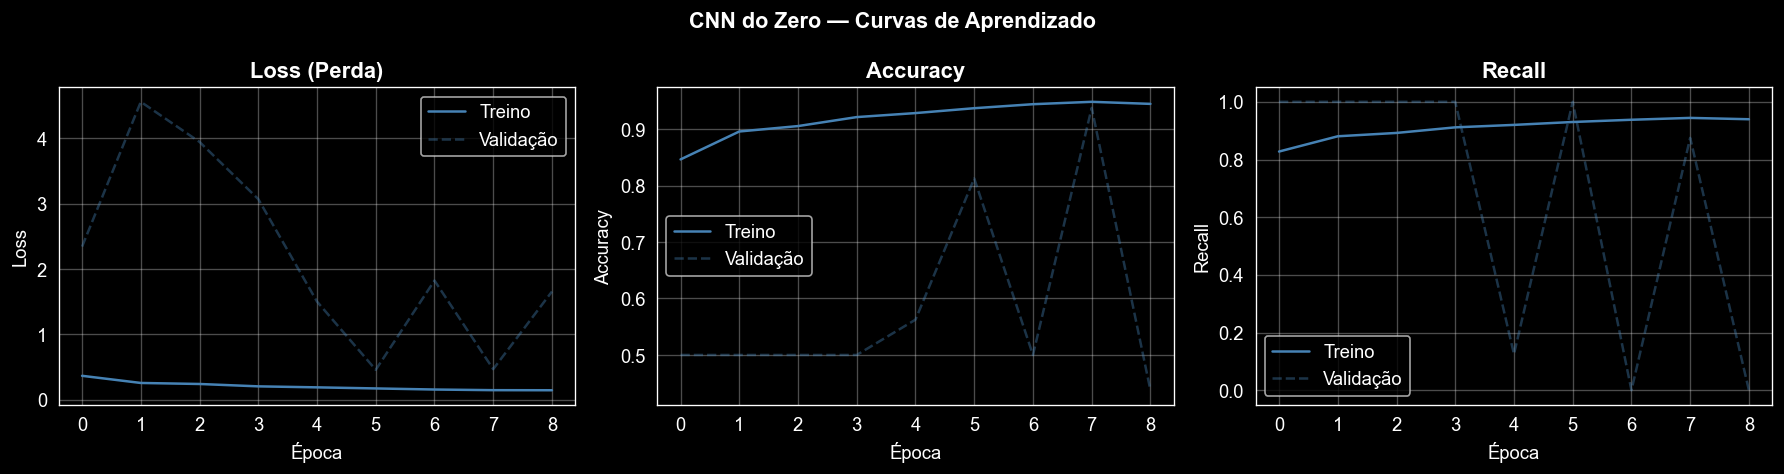

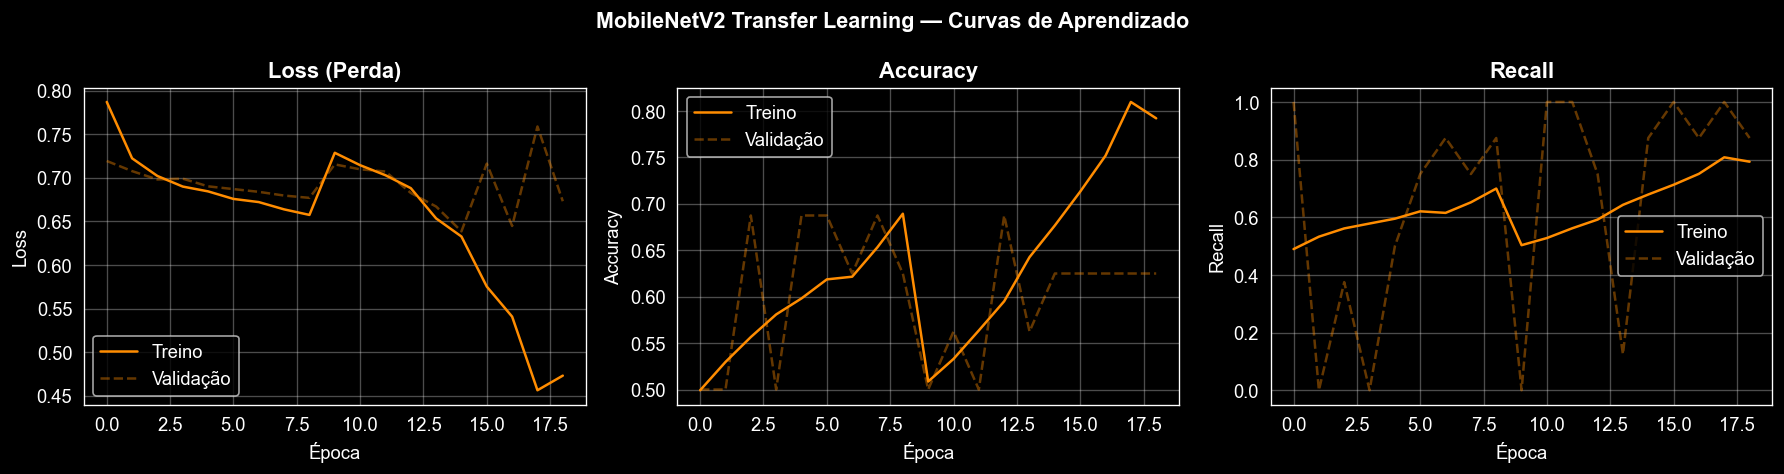

In [15]:
def plotar_historico(history, titulo, cor='steelblue'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metricas = [
        ('loss',     'val_loss',     'Loss (Perda)',    'Loss'),
        ('accuracy', 'val_accuracy', 'Accuracy',        'Accuracy'),
        ('recall',   'val_recall',   'Recall',          'Recall'),
    ]
    for ax, (treino, val, label, ylabel) in zip(axes, metricas):
        ax.plot(history.history[treino], color=cor, label='Treino')
        ax.plot(history.history[val], color=cor, alpha=0.4, linestyle='--', label='Validação')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    nome = titulo.lower().replace(' ', '_').replace('—', '').replace('/', '_')
    plt.savefig(f'../resultados/cnn_curvas_{nome}.png', bbox_inches='tight')
    plt.show()

plotar_historico(history_cnn, 'CNN do Zero — Curvas de Aprendizado', cor='steelblue')

# Concatena os dois históricos do Transfer Learning
hist_tl_concat = {}
for key in history_tl_fase1.history:
    hist_tl_concat[key] = history_tl_fase1.history[key] + history_tl_fase2.history[key]

class FakeHistory:
    def __init__(self, h): self.history = h

plotar_historico(FakeHistory(hist_tl_concat), 'MobileNetV2 Transfer Learning — Curvas de Aprendizado', cor='darkorange')

### Interpretação esperada das curvas

As curvas da CNN baseline e da MobileNetV2 ajudam a responder perguntas diferentes:

- A CNN do zero está memorizando o treino?
- O Transfer Learning estabiliza melhor a validação?
- O fine-tuning melhora o modelo ou aumenta overfitting?
- O recall melhora sem perda excessiva de precision?

Em um experimento médico, essas curvas não devem ser lidas apenas como desempenho técnico. Elas ajudam a avaliar se o modelo está confiável o suficiente para seguir para teste e interpretação.

### 6.5 Avaliação no Conjunto de Teste

A avaliação final é feita no conjunto de teste, que não foi usado para treino nem para ajuste dos pesos. Essa etapa é a mais importante para comparar os modelos.

As métricas avaliadas são:

- **Precision:** entre os exames classificados como pneumonia, quantos realmente eram pneumonia;
- **Recall:** entre os exames que realmente tinham pneumonia, quantos o modelo detectou;
- **F1-score:** equilíbrio entre precision e recall;
- **AUC-ROC:** capacidade de separação entre as classes em diferentes limiares;
- **Matriz de confusão:** mostra diretamente falsos positivos e falsos negativos.

Para este problema, o erro mais crítico é o **falso negativo**: pneumonia classificada como normal.

In [16]:
def avaliar_modelo(model, test_generator, nome):
    test_generator.reset()
    y_prob = model.predict(test_generator, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_generator.classes

    print(f" {'='*55}")
    print(f'  {nome}')
    print(f" {'='*55}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

    auc = roc_auc_score(y_true, y_prob)
    print(f'AUC-ROC: {auc:.4f}')

    return y_true, y_pred, y_prob

# Recriar gerador de teste sem augmentation, sem shuffle
test_gen_tl = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=CLASSES, seed=SEED, shuffle=False
)

yt_cnn, yp_cnn, yprob_cnn = avaliar_modelo(cnn_basica,     test_gen,    'CNN do Zero')
yt_tl,  yp_tl,  yprob_tl  = avaliar_modelo(transfer_model, test_gen_tl, 'MobileNetV2 Transfer Learning')

Found 624 images belonging to 2 classes.
  CNN do Zero
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       234
   Pneumonia       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624

AUC-ROC: 0.4057
  MobileNetV2 Transfer Learning
              precision    recall  f1-score   support

      Normal       0.82      0.17      0.28       234
   Pneumonia       0.66      0.98      0.79       390

    accuracy                           0.67       624
   macro avg       0.74      0.57      0.54       624
weighted avg       0.72      0.67      0.60       624

AUC-ROC: 0.8802


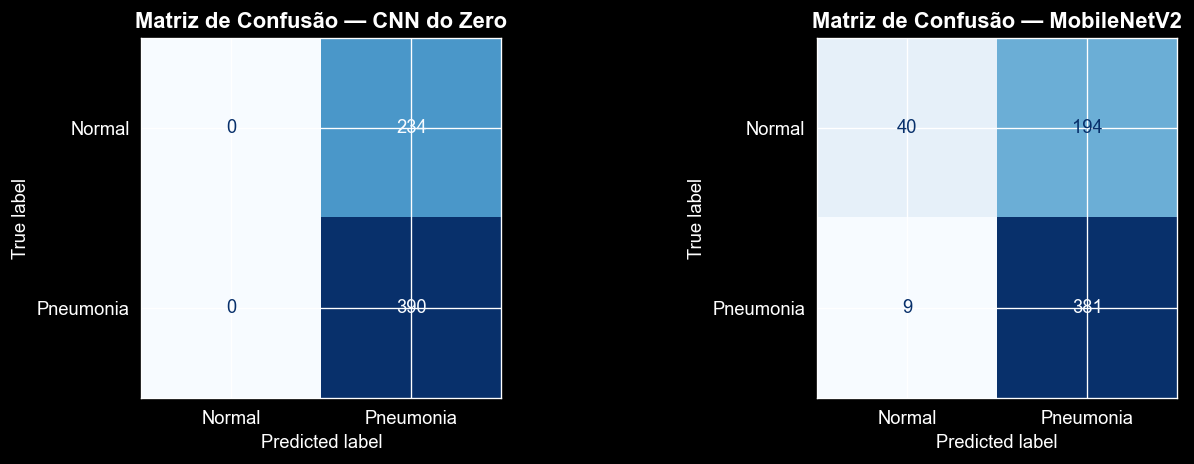

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (yt, yp, nome) in zip(axes, [
    (yt_cnn, yp_cnn, 'CNN do Zero'),
    (yt_tl,  yp_tl,  'MobileNetV2'),
]):
    cm_matrix = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(cm_matrix, display_labels=['Normal', 'Pneumonia'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão — {nome}', fontweight='bold')

plt.tight_layout()
plt.savefig('../resultados/cnn_matrizes_confusao.png', bbox_inches='tight')
plt.show()

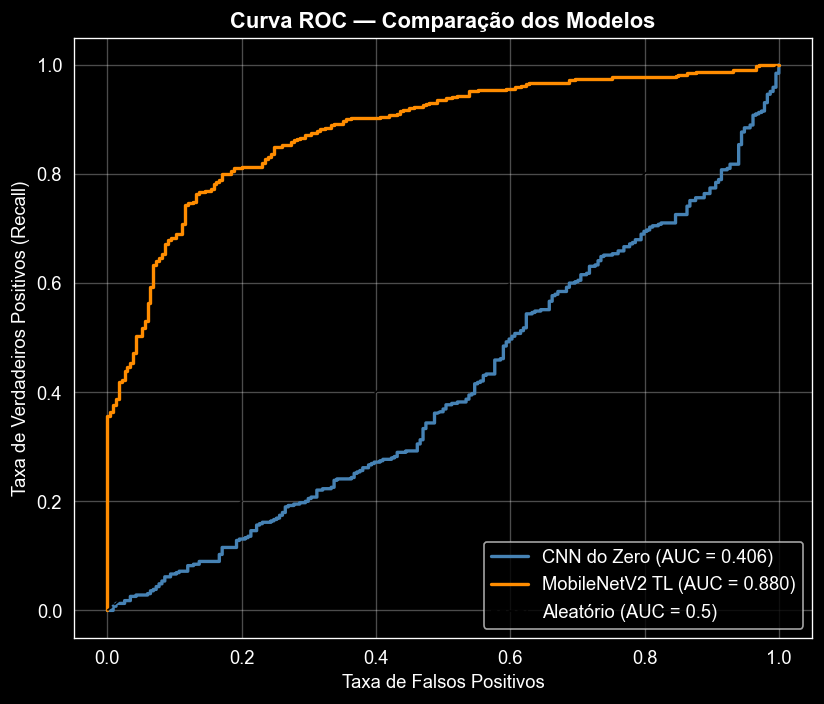

In [18]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for (yt, yprob, nome, cor) in [
    (yt_cnn, yprob_cnn, 'CNN do Zero',      'steelblue'),
    (yt_tl,  yprob_tl,  'MobileNetV2 TL',   'darkorange'),
]:
    fpr, tpr, _ = roc_curve(yt, yprob)
    auc = roc_auc_score(yt, yprob)
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{nome} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=11)
ax.set_title('Curva ROC — Comparação dos Modelos', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../resultados/cnn_curva_roc.png', bbox_inches='tight')
plt.show()

### Análise das matrizes de confusão e da curva ROC

A matriz de confusão mostra os erros de forma direta. Para este problema, o quadrante mais sensível é o de falsos negativos: exames com pneumonia classificados como normais.

A curva ROC complementa essa análise mostrando como o modelo se comporta em diferentes limiares de decisão. Um AUC alto indica boa capacidade de separação, mas não garante que o limiar padrão de 0,5 seja o melhor para uso clínico.

Em uma aplicação real, o limiar deveria ser escolhido considerando o objetivo do sistema. Para triagem, pode fazer sentido aceitar mais falsos positivos em troca de menos falsos negativos.

### 6.6 Tabela Comparativa de Métricas

A tabela comparativa resume os resultados dos dois modelos. Essa visualização facilita identificar o melhor compromisso entre desempenho geral e segurança clínica.

A acurácia pode ser útil como visão geral, mas não deve ser o principal critério de escolha. Em triagem de pneumonia, o Recall da classe Pneumonia é mais importante, pois mede a capacidade do modelo de detectar pacientes realmente doentes.

In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def metricas_resumo(yt, yp, yprob, nome):
    return {
        'Modelo':    nome,
        'Accuracy':  accuracy_score(yt, yp),
        'Recall':    recall_score(yt, yp),
        'Precision': precision_score(yt, yp),
        'F1-Score':  f1_score(yt, yp),
        'AUC-ROC':   roc_auc_score(yt, yprob),
    }

df_resultados = pd.DataFrame([
    metricas_resumo(yt_cnn, yp_cnn, yprob_cnn, 'CNN do Zero'),
    metricas_resumo(yt_tl,  yp_tl,  yprob_tl,  'MobileNetV2 TL'),
]).set_index('Modelo').round(4)

display(df_resultados.style.highlight_max(axis=0, color='#c6efce'))

print('\nMétrica prioritária: RECALL')
print('Em diagnóstico de pneumonia, um falso negativo (doente classificado como saudável)')
print('tem consequências muito mais graves que um falso positivo.')
print('Por isso priorizamos maximizar o Recall (sensibilidade).')

,Accuracy,Recall,Precision,F1-Score,AUC-ROC
Modelo,,,,,
CNN do Zero,0.625000,1.000000,0.625000,0.769200,0.405700
MobileNetV2 TL,0.674700,0.976900,0.662600,0.789600,0.880200



Métrica prioritária: RECALL
Em diagnóstico de pneumonia, um falso negativo (doente classificado como saudável)
tem consequências muito mais graves que um falso positivo.
Por isso priorizamos maximizar o Recall (sensibilidade).


### Análise da comparação final

A tabela final permite comparar os modelos de forma objetiva. O melhor modelo não deve ser escolhido apenas pela acurácia, mas principalmente pelo Recall da classe Pneumonia e pelo número de falsos negativos.

Se dois modelos tiverem desempenho parecido, outros critérios passam a importar:

- estabilidade entre treino, validação e teste;
- custo computacional;
- facilidade de explicação;
- comportamento no Grad-CAM;
- quantidade de falsos positivos aceitável no fluxo de trabalho.

O modelo escolhido deve ser visto como apoio à triagem, não como diagnóstico definitivo.

## 7. Interpretabilidade com Grad-CAM

Além de medir desempenho, é importante entender **onde** o modelo está olhando para tomar decisões. Em aplicações médicas, um modelo com boas métricas ainda pode estar aprendendo atalhos indesejados, como marcas, bordas, textos ou artefatos da imagem.

O **Grad-CAM** (Gradient-weighted Class Activation Mapping) gera mapas de calor que destacam regiões da imagem que mais influenciaram a predição.

### Por que isso importa?

- Ajuda a verificar se a atenção está concentrada nos campos pulmonares;
- Facilita a explicação da predição para revisão humana;
- Pode revelar vieses ou padrões espúrios;
- Não prova que o modelo está correto, mas ajuda a auditar seu comportamento.

A implementação abaixo também trata o caso em que a camada convolucional está dentro de um submodelo, como ocorre com a MobileNetV2.

In [20]:
def _find_conv_layer(model, layer_name=None):
    if layer_name is not None:
        try:
            return model.get_layer(layer_name), None
        except ValueError:
            for layer in model.layers:
                if hasattr(layer, 'layers'):
                    try:
                        return layer.get_layer(layer_name), layer
                    except ValueError:
                        continue
            raise ValueError(f'Camada {layer_name!r} não encontrada no modelo.')

    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer, None

    for layer in reversed(model.layers):
        if hasattr(layer, 'layers'):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, layers.Conv2D):
                    return sub_layer, layer

    raise ValueError('Nenhuma camada Conv2D encontrada para Grad-CAM.')


def _call_inference(layer, x):
    if isinstance(layer, (layers.BatchNormalization, layers.Dropout)):
        return layer(x, training=False)
    return layer(x)


def grad_cam(model, img_array, layer_name=None):
    """Gera mapa de calor Grad-CAM para a última camada convolucional."""
    target_layer, parent_model = _find_conv_layer(model, layer_name)

    if parent_model is None:
        conv_out = target_layer.output
        predictions = model.output
    else:
        parent_idx = next(i for i, layer in enumerate(model.layers) if layer is parent_model)
        parent_input = parent_model._inbound_nodes[0].input_tensors
        if isinstance(parent_input, (list, tuple)) and len(parent_input) == 1:
            parent_input = parent_input[0]

        conv_model = keras.Model(
            inputs=parent_model.input,
            outputs=[target_layer.output, parent_model.output],
            name='gradcam_conv_model',
        )
        conv_out, x = conv_model(parent_input, training=False)

        for layer in model.layers[parent_idx + 1:]:
            x = _call_inference(layer, x)
        predictions = x

    grad_model = keras.Model(inputs=model.inputs, outputs=[conv_out, predictions])

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array[np.newaxis, ...], tf.float32)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise ValueError('Não foi possível calcular os gradientes para a camada convolucional selecionada.')

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(predictions[0][0])


def sobrepor_gradcam(img_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    colormap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colormap_rgb = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)
    superimposed = (img_rgb * (1 - alpha) + colormap_rgb * alpha).astype(np.uint8)
    return superimposed

Found 624 images belonging to 2 classes.


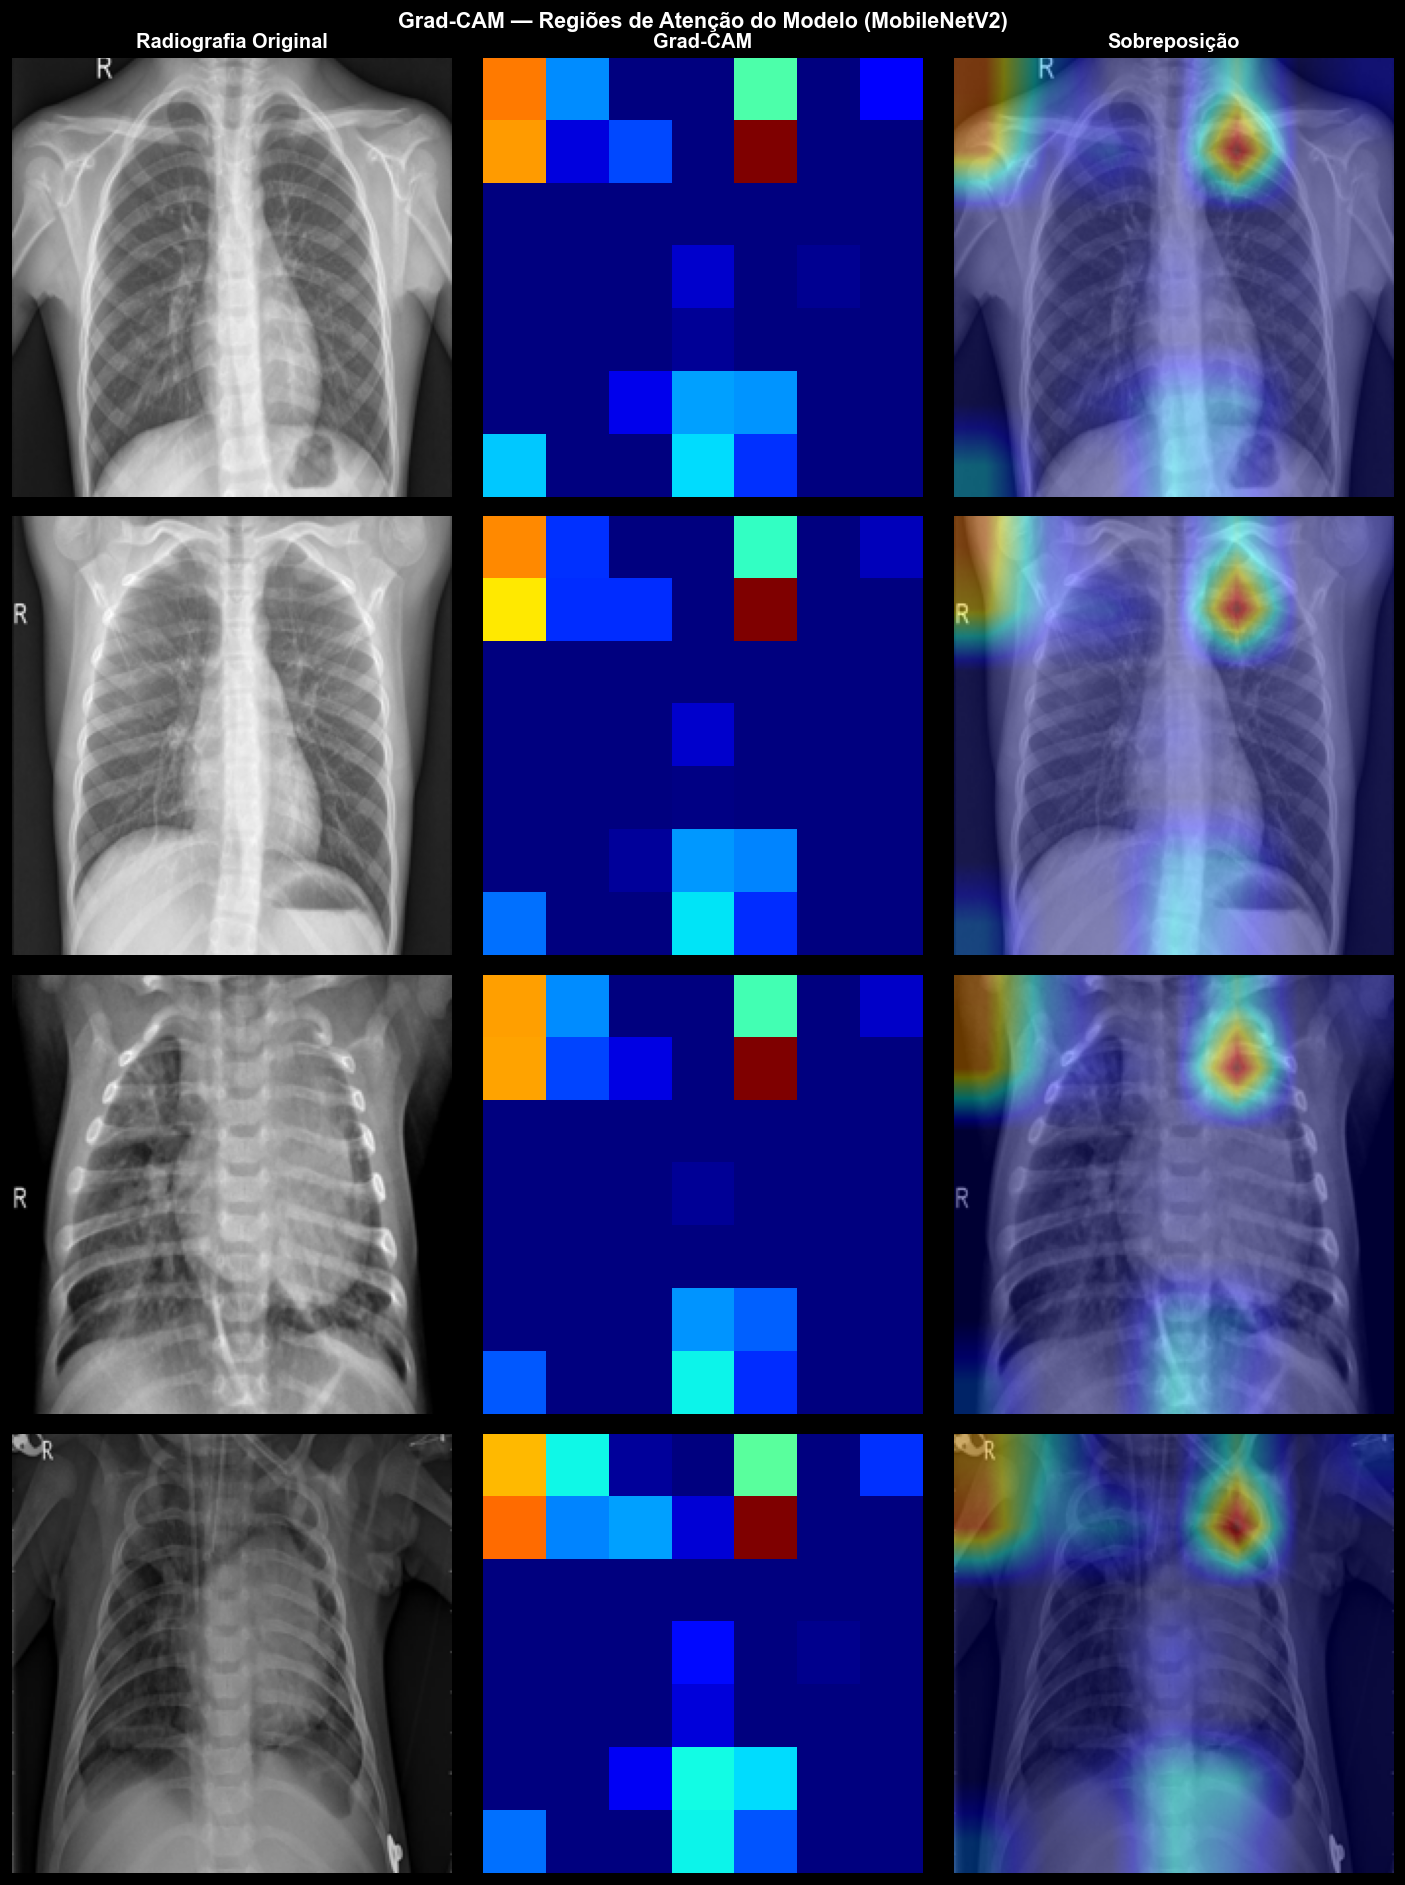

In [21]:
# Seleciona amostras do conjunto de teste
test_gen_gradcam = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=1,
    class_mode='binary', classes=CLASSES, seed=SEED, shuffle=False
)

# Pega 4 amostras (2 NORMAL, 2 PNEUMONIA)
amostras_normal     = list((TEST_DIR / 'NORMAL').glob('*.*'))[:2]
amostras_pneumonia  = list((TEST_DIR / 'PNEUMONIA').glob('*.*'))[:2]
amostras_gradcam    = [(p, 'Normal') for p in amostras_normal] + \
                      [(p, 'Pneumonia') for p in amostras_pneumonia]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
titulos_col = ['Radiografia Original', 'Grad-CAM', 'Sobreposição']

for col, titulo in enumerate(titulos_col):
    axes[0, col].set_title(titulo, fontweight='bold', fontsize=12)

for row, (img_path, classe_real) in enumerate(amostras_gradcam):
    img_rgb = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE))
    img_norm = img_rgb / 255.0

    heatmap, prob = grad_cam(transfer_model, img_norm)
    pred_label = 'Pneumonia' if prob >= 0.5 else 'Normal'
    cor = 'red' if pred_label != classe_real else 'green'

    overlay = sobrepor_gradcam(img_rgb, heatmap)

    axes[row, 0].imshow(img_rgb, cmap='gray')
    axes[row, 0].set_ylabel(f'Real: {classe_real}', fontsize=10)
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_xlabel(f'Predição: {pred_label} ({prob:.2%})', color=cor, fontsize=10)

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Grad-CAM — Regiões de Atenção do Modelo (MobileNetV2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/cnn_gradcam.png', bbox_inches='tight')
plt.show()

### Análise do Grad-CAM

A visualização mostra três elementos para cada imagem: a radiografia original, o mapa de calor e a sobreposição do mapa sobre a imagem.

A interpretação desejada é que as regiões de maior ativação estejam dentro dos campos pulmonares, especialmente em áreas compatíveis com opacidades quando a predição for pneumonia.

Alguns cuidados são importantes:

- Grad-CAM não é prova de causalidade;
- uma região quente fora dos pulmões pode indicar viés;
- mapas difusos ou instáveis reduzem a confiança interpretativa;
- a análise deve ser feita por alguém com conhecimento clínico.

Mesmo com essas limitações, o Grad-CAM torna o modelo mais auditável e aproxima o experimento de uma discussão responsável sobre IA médica.

## 8. Discussão Crítica

### 8.1 Por que o Recall é a métrica principal?

Em diagnóstico de pneumonia, um falso negativo significa que uma radiografia com pneumonia foi classificada como normal. Esse erro pode atrasar atendimento, investigação clínica e início do tratamento.

Por esse motivo, o Recall da classe Pneumonia é a métrica mais importante neste notebook. Ele responde à pergunta: entre todos os pacientes que realmente tinham pneumonia, quantos o modelo conseguiu identificar?

Isso não significa que precision e falsos positivos sejam irrelevantes. Um modelo que classifica tudo como pneumonia teria recall alto, mas causaria muitos alarmes falsos. O objetivo é encontrar um equilíbrio, priorizando sensibilidade sem tornar o modelo inútil na prática.

In [22]:
print('=== Análise dos Erros Críticos ===')
print()

for nome, yt, yp in [('CNN do Zero', yt_cnn, yp_cnn), ('MobileNetV2', yt_tl, yp_tl)]:
    cm_m = confusion_matrix(yt, yp)
    tn, fp, fn, tp = cm_m.ravel()
    print(f'Modelo: {nome}')
    print(f'  Verdadeiros Positivos (TP — Pneumonia detectada):  {tp}')
    print(f'  Falsos Negativos     (FN — Pneumonia não detectada): {fn}  ← CRÍTICO')
    print(f'  Falsos Positivos     (FP — Normal classificado errado): {fp}')
    print(f'  Verdadeiros Negativos (TN — Normal correto):        {tn}')
    print()

=== Análise dos Erros Críticos ===

Modelo: CNN do Zero
  Verdadeiros Positivos (TP — Pneumonia detectada):  390
  Falsos Negativos     (FN — Pneumonia não detectada): 0  ← CRÍTICO
  Falsos Positivos     (FP — Normal classificado errado): 234
  Verdadeiros Negativos (TN — Normal correto):        0

Modelo: MobileNetV2
  Verdadeiros Positivos (TP — Pneumonia detectada):  381
  Falsos Negativos     (FN — Pneumonia não detectada): 9  ← CRÍTICO
  Falsos Positivos     (FP — Normal classificado errado): 194
  Verdadeiros Negativos (TN — Normal correto):        40



### Interpretação dos erros críticos

A célula acima detalha os componentes da matriz de confusão para cada modelo.

- **TP:** pneumonia detectada corretamente;
- **FN:** pneumonia não detectada, o erro mais crítico;
- **FP:** radiografia normal classificada como pneumonia;
- **TN:** radiografia normal classificada corretamente.

Essa análise é mais informativa do que olhar apenas para acurácia. Em contexto clínico, o tipo de erro importa tanto quanto a quantidade total de erros.

### 8.2 O modelo pode ser usado na prática?

Os resultados deste notebook indicam que CNNs podem aprender padrões relevantes em radiografias de tórax e que Transfer Learning é uma estratégia útil quando o volume de dados é limitado. No entanto, este projeto tem caráter **acadêmico e experimental**.

---

### Pontos fortes observados

- Uso de um problema real de visão computacional médica;
- Comparação entre uma CNN treinada do zero e uma arquitetura pré-treinada;
- Tratamento explícito do desbalanceamento com `class_weight`;
- Avaliação com métricas alinhadas ao risco clínico;
- Uso de Grad-CAM para interpretar regiões de atenção do modelo.

---

### Limitações identificadas

- O dataset vem de um contexto pediátrico específico e pode não generalizar para adultos ou outras populações;
- A validação original possui apenas 16 imagens, tornando o ajuste de hiperparâmetros instável;
- O modelo classifica apenas `NORMAL` vs `PNEUMONIA`, sem distinguir pneumonia viral, bacteriana ou outras condições;
- Não houve validação externa com dados de outros hospitais, equipamentos ou protocolos;
- As imagens podem conter padrões de aquisição que o modelo aprende sem relação direta com a doença;
- O treinamento foi feito em ambiente local, sem otimização para produção ou monitoramento contínuo.

---

### Risco dos erros de classificação

Em um fluxo clínico, falsos negativos são o maior risco, mas falsos positivos também têm impacto: podem gerar ansiedade, exames adicionais e sobrecarga na equipe médica.

Por isso, um sistema real precisaria definir o limiar de decisão com apoio de especialistas, considerando o objetivo de uso: triagem, priorização de fila, segunda opinião ou apoio à revisão radiológica.

---

### Recomendação de uso

Este modelo **não deve ser usado como diagnóstico autônomo**. A aplicação mais adequada seria como ferramenta de apoio, por exemplo:

- Priorizar radiografias suspeitas para revisão médica;
- Sinalizar exames que merecem atenção adicional;
- Atuar como segunda leitura automatizada;
- Apoiar estudos acadêmicos sobre visão computacional médica.

A decisão final deve permanecer com o médico radiologista ou profissional responsável pelo cuidado do paciente.

### 8.3 Resumo Final

Este notebook demonstrou um fluxo completo de classificação de radiografias com CNN:

- Carregamento e exploração do dataset;
- Análise de desbalanceamento e dimensões das imagens;
- Pré-processamento com redimensionamento, normalização e data augmentation;
- Treinamento de uma CNN baseline;
- Treinamento com MobileNetV2 e fine-tuning;
- Avaliação por métricas clínicas e matriz de confusão;
- Interpretação visual com Grad-CAM;
- Discussão crítica sobre limites e uso responsável.

Do ponto de vista técnico, o projeto mostra como redes convolucionais podem apoiar problemas de classificação médica. Do ponto de vista prático, também reforça que bons resultados em um dataset público não são suficientes para uso clínico real sem validação externa, governança, monitoramento e revisão especializada.

In [23]:
print('=' * 60)
print('  RESUMO — Detecção de Pneumonia com CNN')
print('=' * 60)
print()
print('Dataset: Chest X-Ray Images (Pneumonia) — Kaggle')
print('Problema: Classificação binária (Normal vs Pneumonia)')
print()
print('Modelos treinados:')
print('  1. CNN do Zero — baseline, treinada do início')
print('  2. MobileNetV2 Transfer Learning + Fine-tuning')
print()
print('Estratégias utilizadas:')
print('  - Data Augmentation (rotação, flip, zoom, deslocamento)')
print('  - class_weight para compensar desbalanceamento')
print('  - EarlyStopping monitorando Recall')
print('  - ReduceLROnPlateau para ajuste dinâmico da taxa de aprendizado')
print('  - Fine-tuning das últimas 30 camadas do MobileNetV2')
print()
print('Interpretabilidade: Grad-CAM confirma foco nas regiões pulmonares')
print()
print(df_resultados.to_string())

  RESUMO — Detecção de Pneumonia com CNN

Dataset: Chest X-Ray Images (Pneumonia) — Kaggle
Problema: Classificação binária (Normal vs Pneumonia)

Modelos treinados:
  1. CNN do Zero — baseline, treinada do início
  2. MobileNetV2 Transfer Learning + Fine-tuning

Estratégias utilizadas:
  - Data Augmentation (rotação, flip, zoom, deslocamento)
  - class_weight para compensar desbalanceamento
  - EarlyStopping monitorando Recall
  - ReduceLROnPlateau para ajuste dinâmico da taxa de aprendizado
  - Fine-tuning das últimas 30 camadas do MobileNetV2

Interpretabilidade: Grad-CAM confirma foco nas regiões pulmonares

                Accuracy  Recall  Precision  F1-Score  AUC-ROC
Modelo                                                        
CNN do Zero       0.6250  1.0000     0.6250    0.7692   0.4057
MobileNetV2 TL    0.6747  0.9769     0.6626    0.7896   0.8802


### Conclusão geral

O fluxo desenvolvido mostra que CNNs podem ser aplicadas a radiografias para apoiar tarefas de classificação. O uso de Transfer Learning com MobileNetV2 é especialmente interessante por reduzir o esforço de treinamento e aproveitar representações visuais já aprendidas.

A principal conclusão, porém, não é que o modelo está pronto para uso clínico. A conclusão mais importante é que um projeto de IA médica precisa combinar desempenho, interpretação, validação externa e análise crítica dos riscos.

Para evoluir este trabalho, os próximos passos seriam:

- validar em datasets externos;
- testar limiares de decisão diferentes de 0,5;
- comparar outras arquiteturas pré-treinadas;
- avaliar resolução de imagem maior;
- incluir validação por especialista;
- investigar explicabilidade em casos de erro.